# **IMPORT LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


# **LOAD HOUSING DATASET**

In [2]:
housing = fetch_california_housing(
    as_frame=True
)

df = housing.frame.copy()

print("\nDataset loaded successfully!")


Dataset loaded successfully!


## DISPLAY DATASET

In [3]:
print("\nFirst 10 records:")

display(
    df.head(10)
)


First 10 records:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


## DATASET SIZE

In [4]:
print("\nDataset Shape:")
print(df.shape)

print(
    f"\nNumber of observations: {df.shape[0]}"
)

print(
    f"Number of variables: {df.shape[1]}"
)


Dataset Shape:
(20640, 9)

Number of observations: 20640
Number of variables: 9


## DATASET INFORMATION


In [45]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


##  STATISTICAL SUMMARY

In [5]:
print("\nStatistical Summary:")

display(
    df.describe()
)


Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## CHECK MISSING VALUES

In [6]:
print("\nMissing Values:")

display(
    df.isnull().sum()
)


Missing Values:


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


## CHECK DUPLICATES


In [7]:
print("\nDuplicate Records:")

print(
    df.duplicated().sum()
)


Duplicate Records:
0


## DISPLAY FEATURE DESCRIPTIONS


In [9]:
print("\nFeature Descriptions:")

feature_description = {
    "MedInc": "Median income in the block group",
    "HouseAge": "Median house age in the block group",
    "AveRooms": "Average number of rooms per household",
    "AveBedrms": "Average number of bedrooms per household",
    "Population": "Block group population",
    "AveOccup": "Average number of household members",
    "Latitude": "Latitude of the block group",
    "Longitude": "Longitude of the block group",
    "MedHouseVal": "Median house value (target)"
}

for feature, description in feature_description.items():
    print(f"{feature}: {description}")


Feature Descriptions:
MedInc: Median income in the block group
HouseAge: Median house age in the block group
AveRooms: Average number of rooms per household
AveBedrms: Average number of bedrooms per household
Population: Block group population
AveOccup: Average number of household members
Latitude: Latitude of the block group
Longitude: Longitude of the block group
MedHouseVal: Median house value (target)


# **CORRELATION MATRIX**

In [8]:
correlation_matrix = df.corr()

print("\nCorrelation Matrix:")

display(
    correlation_matrix
)


Correlation Matrix:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


## CORRELATION WITH TARGET


In [10]:
target_correlation = (
    correlation_matrix["MedHouseVal"]
    .sort_values(
        ascending=False
    )
)

print(
    "\nCorrelation with Median House Value:"
)

display(
    target_correlation
)


Correlation with Median House Value:


,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


# **CORRELATION HEATMAP**

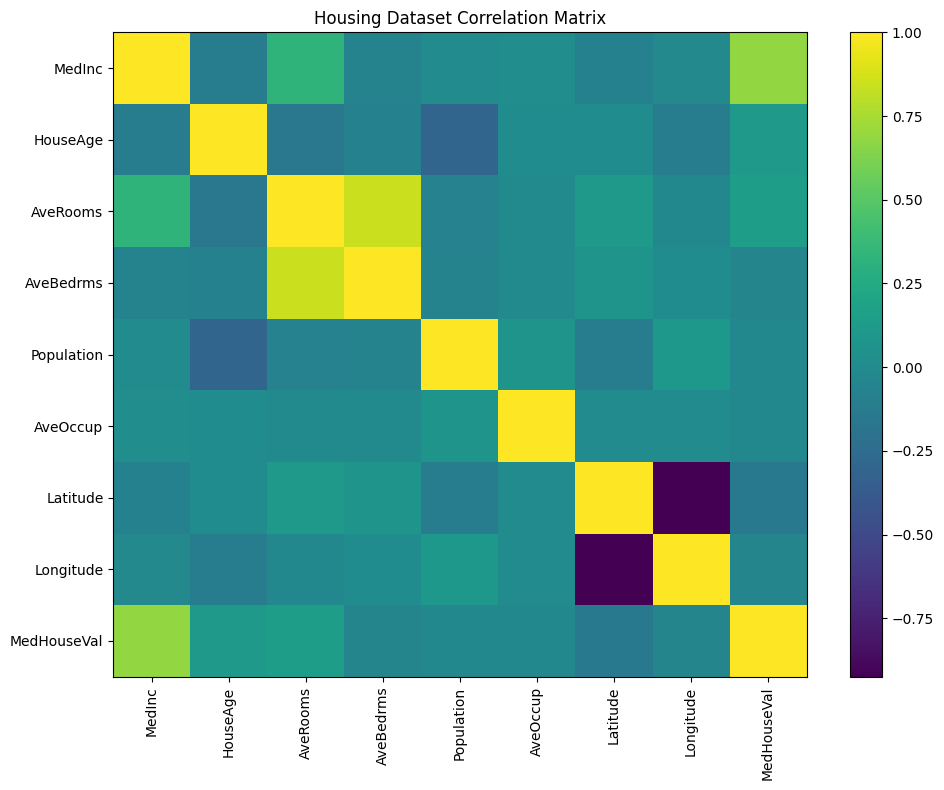

In [11]:
plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title(
    "Housing Dataset Correlation Matrix"
)

plt.tight_layout()

plt.show()

# **MEDIAN INCOME VS HOUSE VALUE**

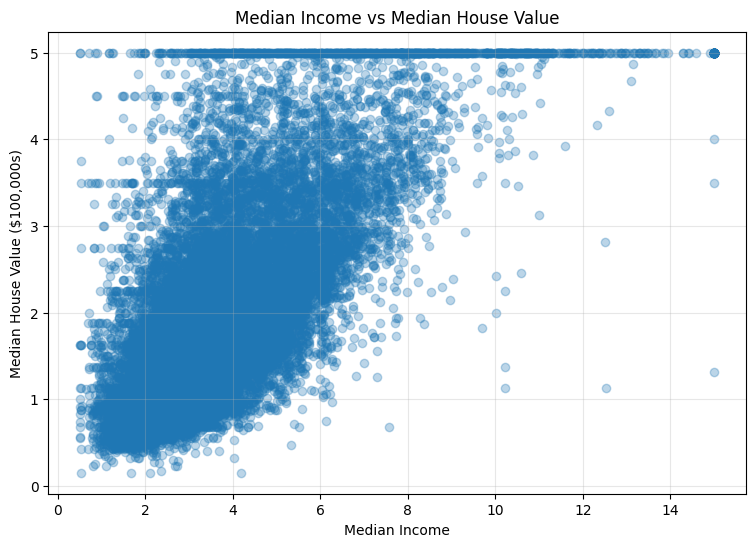

In [12]:
plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    alpha=0.3
)

plt.xlabel(
    "Median Income"
)

plt.ylabel(
    "Median House Value ($100,000s)"
)

plt.title(
    "Median Income vs Median House Value"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()

# **HOUSE AGE VS HOUSE VALUE**

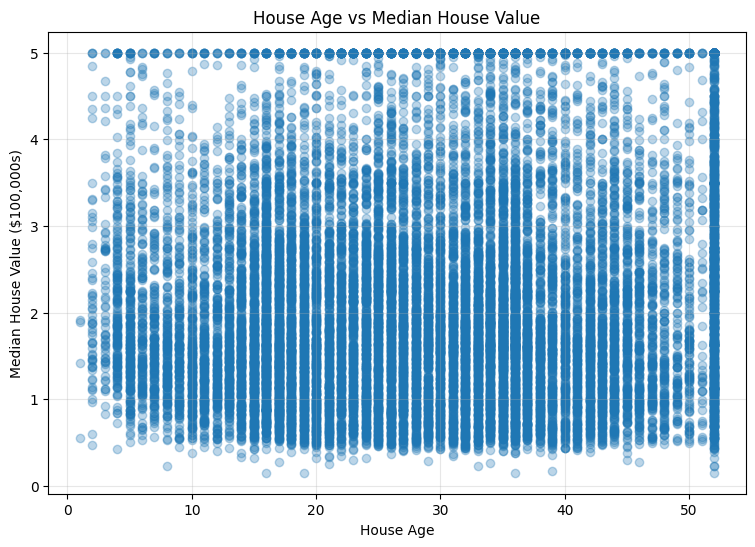

In [13]:
plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    df["HouseAge"],
    df["MedHouseVal"],
    alpha=0.3
)

plt.xlabel(
    "House Age"
)

plt.ylabel(
    "Median House Value ($100,000s)"
)

plt.title(
    "House Age vs Median House Value"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()

##  DEFINE FEATURES AND TARGET


In [14]:
features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude"
]

# Independent variables
X = df[features]

# Dependent variable / Target
y = df["MedHouseVal"]

print("\nIndependent Variables:")
print(features)

print("\nDependent Variable:")
print("MedHouseVal")


Independent Variables:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Dependent Variable:
MedHouseVal


## TRAIN-TEST SPLIT

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(
    "\nTraining observations:",
    len(X_train)
)

print(
    "Testing observations:",
    len(X_test)
)


Training observations: 16512
Testing observations: 4128


##  CREATE LINEAR REGRESSION MODEL


In [24]:
model = LinearRegression()

print(
    "\nLinear Regression model created."
)


Linear Regression model created.


## TRAIN MODEL


In [25]:
model.fit(
    X_train,
    y_train
)

print(
    "Model training completed successfully!"
)

Model training completed successfully!


##  MODEL INTERCEPT

In [26]:
print(
    "\nModel Intercept:"
)

print(
    model.intercept_
)


Model Intercept:
-37.02327770606409


# **REGRESSION COEFFICIENTS**

In [27]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print(
    "\nRegression Coefficients:"
)

display(
    coefficients
)


Regression Coefficients:


,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


# **REGRESSION EQUATION**

In [28]:
equation = (
    f"MedHouseVal = "
    f"{model.intercept_:.4f}"
)

for feature, coefficient in zip(
    features,
    model.coef_
):
    sign = "+" if coefficient >= 0 else "-"

    equation += (
        f" {sign} "
        f"{abs(coefficient):.4f}({feature})"
    )

print("\nMULTIPLE LINEAR REGRESSION EQUATION")
print("=====================================")
print(equation)


MULTIPLE LINEAR REGRESSION EQUATION
MedHouseVal = -37.0233 + 0.4487(MedInc) + 0.0097(HouseAge) - 0.1233(AveRooms) + 0.7831(AveBedrms) - 0.0000(Population) - 0.0035(AveOccup) - 0.4198(Latitude) - 0.4337(Longitude)


## MAKE PREDICTIONS

In [29]:
y_pred = model.predict(
    X_test
)

print(
    "\nPredictions generated successfully!"
)


Predictions generated successfully!


##  ACTUAL VS PREDICTED VALUES


In [30]:
results = pd.DataFrame({
    "Actual_Value": y_test.values,
    "Predicted_Value": y_pred
})

results["Error"] = (
    results["Actual_Value"]
    - results["Predicted_Value"]
)

results["Absolute_Error"] = (
    results["Error"].abs()
)

print(
    "\nActual vs Predicted Values:"
)

display(
    results.head(20)
)


Actual vs Predicted Values:


,Actual_Value,Predicted_Value,Error,Absolute_Error
0,0.47700,0.719123,-0.242123,0.242123
1,0.45800,1.764017,-1.306017,1.306017
2,5.00001,2.709659,2.290351,2.290351
3,2.18600,2.838926,-0.652926,0.652926
4,2.78000,2.604657,0.175343,0.175343
5,1.58700,2.011754,-0.424754,0.424754
6,1.98200,2.645500,-0.663500,0.663500
7,1.57500,2.168755,-0.593755,0.593755
8,3.40000,2.740746,0.659254,0.659254
9,4.46600,3.915615,0.550385,0.550385


## MEAN ABSOLUTE ERROR


In [31]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print(
    f"\nMAE: {mae:.4f}"
)


MAE: 0.5332


## MEAN SQUARED ERROR


In [32]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print(
    f"MSE: {mse:.4f}"
)

MSE: 0.5559


##  ROOT MEAN SQUARED ERROR


In [34]:
rmse = np.sqrt(mse)

print(
    f"RMSE: {rmse:.4f}"
)

RMSE: 0.7456


## R-SQUARED

In [33]:
r2 = r2_score(
    y_test,
    y_pred
)

print(
    f"R² Score: {r2:.4f}"
)

print(
    f"R² Percentage: {r2 * 100:.2f}%"
)

R² Score: 0.5758
R² Percentage: 57.58%


## DISPLAY ALL METRICS

In [35]:
evaluation = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

print("\nMODEL PERFORMANCE")

display(evaluation)


MODEL PERFORMANCE


,Metric,Value
0,MAE,0.533200
1,MSE,0.555892
2,RMSE,0.745581
3,R²,0.575788


# **ACTUAL VS PREDICTED PLOT**

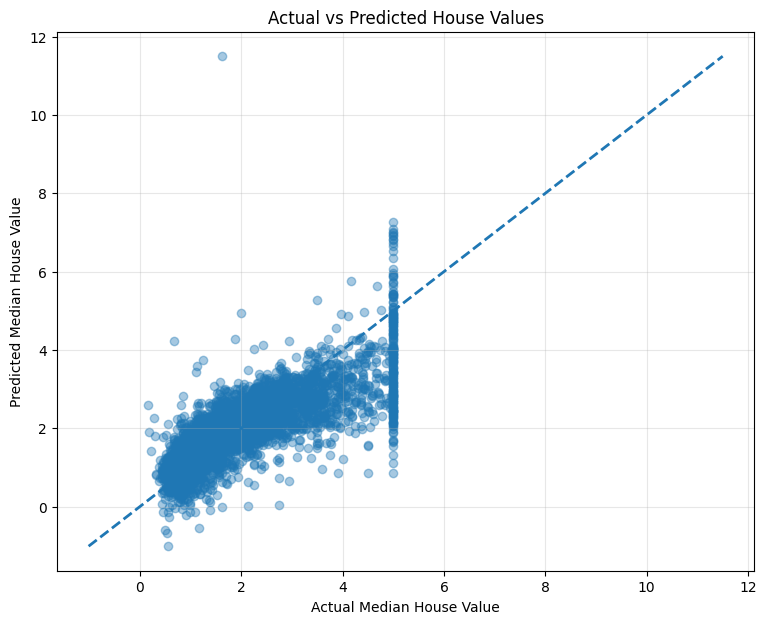

In [36]:
plt.figure(
    figsize=(9, 7)
)

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

# Perfect prediction line
minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Actual Median House Value"
)

plt.ylabel(
    "Predicted Median House Value"
)

plt.title(
    "Actual vs Predicted House Values"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()

# **RESIDUAL PLOT**

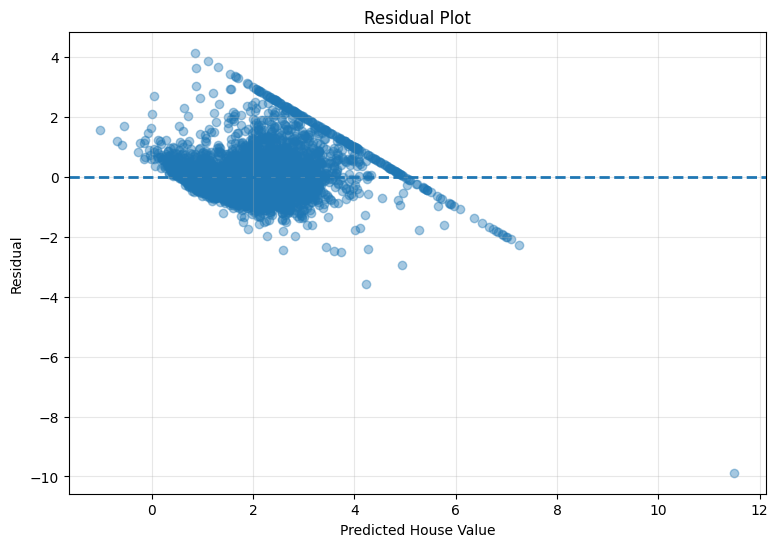

In [37]:
residuals = (
    y_test - y_pred
)

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    y_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Predicted House Value"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residual Plot"
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()

# **FEATURE COEFFICIENT VISUALIZATION**

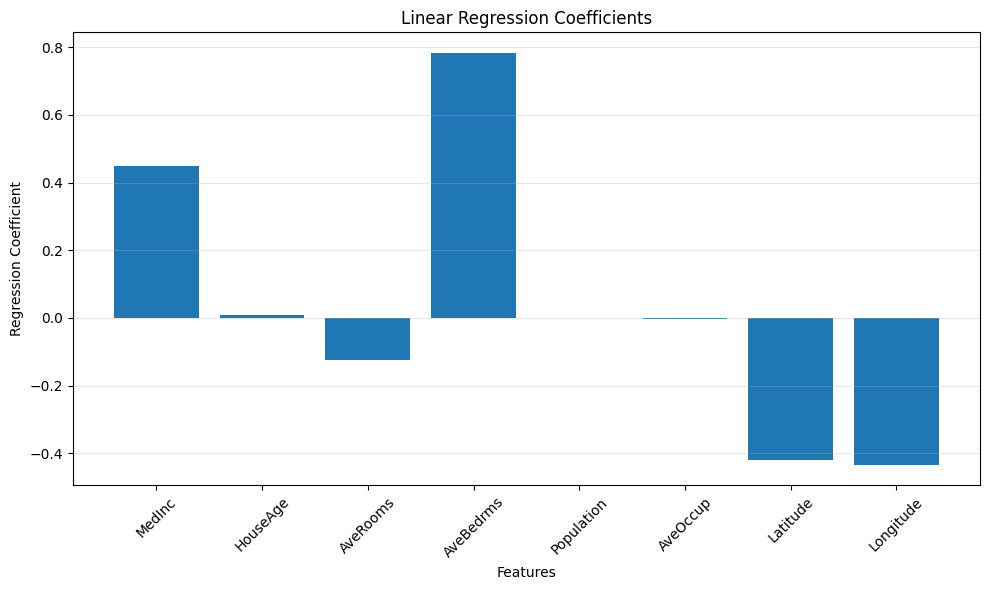

In [38]:
plt.figure(
    figsize=(10, 6)
)

plt.bar(
    features,
    model.coef_
)

plt.xlabel(
    "Features"
)

plt.ylabel(
    "Regression Coefficient"
)

plt.title(
    "Linear Regression Coefficients"
)

plt.xticks(
    rotation=45
)

plt.grid(
    True,
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

## PREDICT A NEW HOUSE

In [39]:
new_house = pd.DataFrame({
    "MedInc": [5.0],
    "HouseAge": [25.0],
    "AveRooms": [6.0],
    "AveBedrms": [1.2],
    "Population": [1500],
    "AveOccup": [3.0],
    "Latitude": [34.0],
    "Longitude": [-118.0]
})

new_prediction = model.predict(
    new_house
)

print("\nNEW HOUSE PREDICTION")
print("========================")

display(
    new_house
)

print(
    f"\nPredicted house value: "
    f"${new_prediction[0] * 100000:,.2f}"
)


NEW HOUSE PREDICTION


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,5.0,25.0,6.0,1.2,1500,3.0,34.0,-118.0



Predicted house value: $255,402.08


### **SAVE DATASET**

In [40]:
df.to_csv(
    "california_housing_dataset.csv",
    index=False
)

print(
    "\nDataset saved as:"
)

print(
    "california_housing_dataset.csv"
)


Dataset saved as:
california_housing_dataset.csv


### **SAVE PREDICTIONS**

In [43]:
results.to_csv(
    "housing_predictions.csv",
    index=False
)

print(
    "\nPredictions saved as:"
)

print(
    "housing_predictions.csv"
)


Predictions saved as:
housing_predictions.csv


## DOWNLOAD FILES IN GOOGLE COLAB


In [44]:
from google.colab import files

files.download(
    "california_housing_dataset.csv"
)

files.download(
    "housing_predictions.csv"
)

print(
    "\nFiles downloaded successfully!"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Files downloaded successfully!
